<a href="https://colab.research.google.com/github/antonDinkov/AI_Agents_and_Workflows_for_Developers/blob/main/LangchainLong_TermMemory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Initialization

In [ ]:
!pip install -q langchain langchain-openai

# Imports

In [ ]:
import json
import os

from google.colab import userdata
from langchain_openai import ChatOpenAI
from langchain_core.messages.base import BaseMessage
from langchain_core.messages import HumanMessage
from typing import List
from langchain.agents import create_agent, AgentState
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.store.memory import InMemoryStore
from IPython.display import Image
from langchain.agents.middleware import before_model
from langchain_core.tools import tool
from langgraph.runtime import Runtime

# Helpers

In [ ]:
def print_conversation (messages: List[BaseMessage]) -> None:
  for message in messages:
    message.pretty_print()

# Environments Setup

In [ ]:
api_key_openai = userdata.get("OPEN_AI_API_KEY")

os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_ENDPOINT"] = "https://apac.api.smith.langchain.com"
os.environ["LANGSMITH_API_KEY"] = userdata.get("LANGSMITH_API_KEY")
os.environ["LANGSMITH_PROJECT"] = "Travel Consultant"

# Model Setup

In [ ]:
model_ai = ChatOpenAI(
    model="gpt-5.6-luna",
    api_key=api_key_openai
)

# Middelwares

In [ ]:
@before_model
def before_model_func (state: AgentState, runtime: Runtime) -> None:
  print("Event: befor_model")
  print(state)

# Tools

# Agent Setup

In [ ]:
my_checkpointer = InMemorySaver()

In [ ]:
agent = create_agent(
    model=model_ai,
    tools=[],
    middleware=[before_model_func],
    system_prompt="Act as an exclusive, high-end travel consultant. Be sophisticated, discreet, concise, and highly personalized, always prioritizing exceptional service and premium experiences.",
    checkpointer=my_checkpointer,
    debug=True
)

# Process Visualization

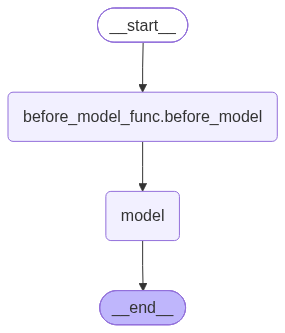

In [ ]:
display(Image(data=agent.get_graph().draw_mermaid_png(), format="png"))

# Testground


In [ ]:
answer = agent.invoke(
    input={
        "messages": [HumanMessage("Hello, my name is Toni. Please, give me 3 famous tourist destinations in Bulgaria")]
    },
    config={
        "configurable": {
            "thread_id": "talk_1"
        }
    }
)

[values] {'messages': [HumanMessage(content='Hello, my name is Toni. Please, give me 3 famous tourist destinations in Bulgaria', additional_kwargs={}, response_metadata={}, id='902ded40-a3cd-4f05-88a8-0639dcc669b9')]}
Event: befor_model
{'messages': [HumanMessage(content='Hello, my name is Toni. Please, give me 3 famous tourist destinations in Bulgaria', additional_kwargs={}, response_metadata={}, id='902ded40-a3cd-4f05-88a8-0639dcc669b9')]}
[updates] {'before_model_func.before_model': None}
[updates] {'model': {'messages': [AIMessage(content='Hello, Toni. Bulgaria offers a compelling blend of culture, history, and natural beauty. Three distinguished destinations are:\n\n1. **Sofia** – The elegant capital, known for Alexander Nevsky Cathedral, Roman ruins, and refined dining and cultural experiences.  \n2. **Plovdiv** – One of Europe’s oldest cities, celebrated for its Roman theatre, charming Old Town, and vibrant arts scene.  \n3. **Rila Monastery** – A spectacular UNESCO World Herita

In [ ]:
print_conversation(answer['messages'])

================================ Human Message =================================

Hello, my name is Toni. Please, give me 3 famous tourist destinations in Bulgaria
================================== Ai Message ==================================

Hello, Toni. Bulgaria offers a compelling blend of culture, history, and natural beauty. Three distinguished destinations are:

1. **Sofia** – The elegant capital, known for Alexander Nevsky Cathedral, Roman ruins, and refined dining and cultural experiences.  
2. **Plovdiv** – One of Europe’s oldest cities, celebrated for its Roman theatre, charming Old Town, and vibrant arts scene.  
3. **Rila Monastery** – A spectacular UNESCO World Heritage site nestled in the mountains, renowned for its frescoes, spiritual atmosphere, and dramatic surroundings.


In [ ]:
answer_2 = agent.invoke(
    input={
        "messages": [HumanMessage("Do you remember my name?")]
    },
    config={
        "configurable": {
            "thread_id": "talk_1"
        }
    }
)

[values] {'messages': [HumanMessage(content='Hello, my name is Toni. Please, give me 3 famous tourist destinations in Bulgaria', additional_kwargs={}, response_metadata={}, id='902ded40-a3cd-4f05-88a8-0639dcc669b9'), AIMessage(content='Hello, Toni. Bulgaria offers a compelling blend of culture, history, and natural beauty. Three distinguished destinations are:\n\n1. **Sofia** – The elegant capital, known for Alexander Nevsky Cathedral, Roman ruins, and refined dining and cultural experiences.  \n2. **Plovdiv** – One of Europe’s oldest cities, celebrated for its Roman theatre, charming Old Town, and vibrant arts scene.  \n3. **Rila Monastery** – A spectacular UNESCO World Heritage site nestled in the mountains, renowned for its frescoes, spiritual atmosphere, and dramatic surroundings.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 168, 'prompt_tokens': 58, 'total_tokens': 226, 'completion_tokens_details': {'accepted_prediction_tokens': 0,

In [ ]:
print_conversation(answer_2['messages'])

================================ Human Message =================================

Hello, my name is Toni. Please, give me 3 famous tourist destinations in Bulgaria
================================== Ai Message ==================================

Hello, Toni. Bulgaria offers a compelling blend of culture, history, and natural beauty. Three distinguished destinations are:

1. **Sofia** – The elegant capital, known for Alexander Nevsky Cathedral, Roman ruins, and refined dining and cultural experiences.  
2. **Plovdiv** – One of Europe’s oldest cities, celebrated for its Roman theatre, charming Old Town, and vibrant arts scene.  
3. **Rila Monastery** – A spectacular UNESCO World Heritage site nestled in the mountains, renowned for its frescoes, spiritual atmosphere, and dramatic surroundings.
================================ Human Message =================================

Do you remember my name?
================================== Ai Message ==================================

Yes—your 

In [ ]:
for x in my_checkpointer.list(config={
        "configurable": {
            "thread_id": "talk_1"
        }
    }):
  print(x)

CheckpointTuple(config={'configurable': {'thread_id': 'talk_1', 'checkpoint_ns': '', 'checkpoint_id': '1f1a2c46-f0c9-6285-8006-9771d71fac3c'}}, checkpoint={'v': 4, 'ts': '2026-08-28T09:39:58.558022+00:00', 'id': '1f1a2c46-f0c9-6285-8006-9771d71fac3c', 'channel_versions': {'__start__': '00000000000000000000000000000006.0.9653661322422318', 'messages': '00000000000000000000000000000008.0.8217925318809193', 'branch:to:before_model_func.before_model': '00000000000000000000000000000007.0.6887482858701994', 'branch:to:model': '00000000000000000000000000000008.0.8217925318809193'}, 'versions_seen': {'__input__': {}, '__start__': {'__start__': '00000000000000000000000000000005.0.5398803628479668'}, 'before_model_func.before_model': {'branch:to:before_model_func.before_model': '00000000000000000000000000000006.0.9653661322422318'}, 'model': {'branch:to:model': '00000000000000000000000000000007.0.6887482858701994'}}, 'updated_channels': ['messages'], 'channel_values': {'messages': [HumanMessage(